## **Forward Propagation from Scratch**

### **Objective**

The goal of this notebook is to understand how a neural network performs **forward propagation** without using TensorFlow or PyTorch

Every computation will be implemented manually using **NumPy**

Instead of treating a neural network as a black box, we will visualize every important step including:

- Input Image
- Pixels
- Weights
- Bias
- Hidden Layer
- Activation
- Output Prediction

By the end of this notebook, we will understand exactly how information flows inside a neural network

In [2]:
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.graph_objects as go

plt.style.use("dark_background")
sns.set_theme(style="white")

np.random.seed(42)

### **Why do we use `np.random.seed(42)`?**

- Neural networks initialize weights randomly.
- Fixing the random seed ensures that every time this notebook is executed, the same random weights are generated
- This makes our experiments reproducible

### **Create a Toy Image**

- Instead of using a real dataset, we will begin with a small grayscale image
- A small image allows us to manually observe every pixel and understand how the neural network processes visual information

In [3]:
image = np.array([
    [20, 30, 40, 20],
    [50, 220, 230, 40],
    [40, 210, 240, 30],
    [20, 30, 20, 10]
])

print(image)

[[ 20  30  40  20]
 [ 50 220 230  40]
 [ 40 210 240  30]
 [ 20  30  20  10]]


### **Visualizing the Input Image**

- Although this image is simply a matrix of numbers, a computer interprets it as pixel intensities
- Higher values correspond to brighter pixels

**`Let's visualize it`**

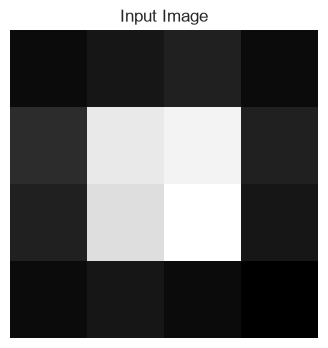

In [7]:
plt.figure(figsize=(4,4))

plt.imshow(image, cmap="gray")

plt.title("Input Image")

plt.axis("off")

plt.show()

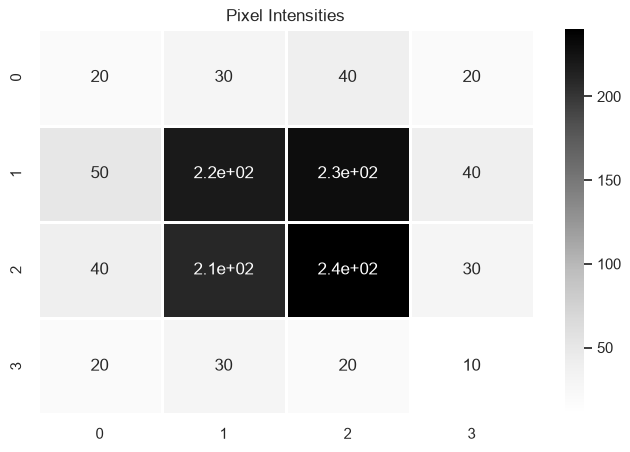

In [9]:
plt.figure(figsize=(8,5))

sns.heatmap(
    image,
    annot=True,
    cmap="Greys",
    cbar=True,
    linewidths=1
)

plt.title("Pixel Intensities")

plt.show()

### **Deep Learning Insight**

A neural network does not `"see" an image the way humans do`

For a neural network, an image is simply a collection of numerical pixel values

The task of the network is to learn meaningful patterns from these numbers

### **Step 2: Flatten the Image**

A neural network cannot directly process a 2D image

Instead, the image is converted into a **1D feature vector**

This process is called **Flattening**

Our 4×4 image contains:

- 4 Rows
- 4 Columns

Total Features:

4 × 4 = **16 Pixels**

Each pixel becomes one input neuron in the neural network

In [10]:
# Flatten the image

image_flat = image.flatten()

print("Shape:", image_flat.shape)

print(image_flat)

Shape: (16,)
[ 20  30  40  20  50 220 230  40  40 210 240  30  20  30  20  10]




The neural network does not know that these values came from an image.

For the network, they are simply **16 numerical features**.

Each feature will become one input neuron.

### **visualizing the Flattened Image**

Let's compare the original image with its flattened representation

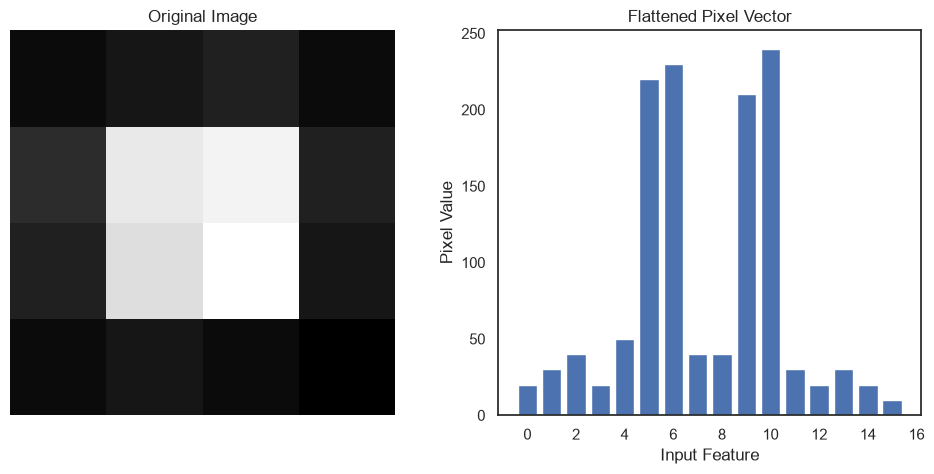

In [11]:
fig, axes = plt.subplots(1,2,figsize=(12,5))

# Original Image

axes[0].imshow(image,cmap="gray")

axes[0].set_title("Original Image")

axes[0].axis("off")

# Flattened Vector

axes[1].bar(range(len(image_flat)),image_flat)

axes[1].set_title("Flattened Pixel Vector")

axes[1].set_xlabel("Input Feature")

axes[1].set_ylabel("Pixel Value")

plt.show()

### **Creating the Input Layer**

Each pixel of the flattened image becomes one neuron in the input layer

Since our image contains **16 pixels**, the input layer will contain **16 neurons**

In [12]:
num_inputs = len(image_flat)

print("Number of Input Neurons:",num_inputs)

Number of Input Neurons: 16


In [ ]:
import plotly.graph_objects as go

# Mock data for demonstration (replace with your actual array/list)
image_flat = [0.1, 0.5, 0.9, 0.2, 0.0, 0.8, 0.4, 0.3, 0.7, 0.6, 0.2, 0.1, 0.9, 0.5, 0.0, 0.4]

fig = go.Figure()

# Generate coordinate distributions
x_positions = [0] * 16
y_positions = list(range(15, -1, -1))

# Generate text labels and hover text lists
text_labels = [str(val) for val in image_flat]
hover_texts = [
    f"<b>Input Neuron {i+1}</b><br>Pixel Value: {val}<extra></extra>"
    for i, val in enumerate(image_flat)
]

# Add everything in a single, fast trace
fig.add_trace(
    go.Scatter(
        x=x_positions,
        y=y_positions,
        mode="markers+text",
        marker=dict(
            size=28,
            color="royalblue"
        ),
        text=text_labels,
        textposition="middle center",
        hoverinfo="text",
        hovertext=hover_texts
    )
)

fig.update_layout(
    title="Input Layer (16 Neurons)",
    xaxis=dict(visible=False),
    yaxis=dict(visible=False),
    height=800,
    plot_bgcolor="white",
    showlegend=False  # Hides a single redundant legend item
)

fig.show()
